In [4]:
import dreams_python

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# High Frequency Snapshots

For the DREAMS Resolution Varied Suite (Garcia et al. In Preparation; as well as other future suites!!) we offer high frequency timestepping of the halo evolving through cosmic time.

In the Resolution Varied Suite, all of the simulations have "mini snapshots" that are created every 10 Myr starting at z=10

In [6]:
rvs = dreams_python.DREAMS('/standard/DREAMS',suite='varied_mass',DM_type='CDM',sobol_number=9, box_or_run='run')

In [7]:
run  = 1
nsnaps = rvs.get_nsnaps_high_frequency(run)

print(f'Run {run} has {nsnaps} snapshots')

Run 1 has 1315 snapshots


In [10]:
from scipy.integrate import quad

def scalefactor_to_age(a_array, H0, Om0):
    def integrand(a):
        return 1.0 / (a * np.sqrt(Om0 * a**-3 + (1 - Om0)))

    H0_gyr = H0 / (3.086e+19)  # Convert H0 from km/s/Mpc to 1/Gyr
    ages = np.array([quad(integrand, a, 1)[0] for a in a_array])
    return ages / H0_gyr / 3.1536e16

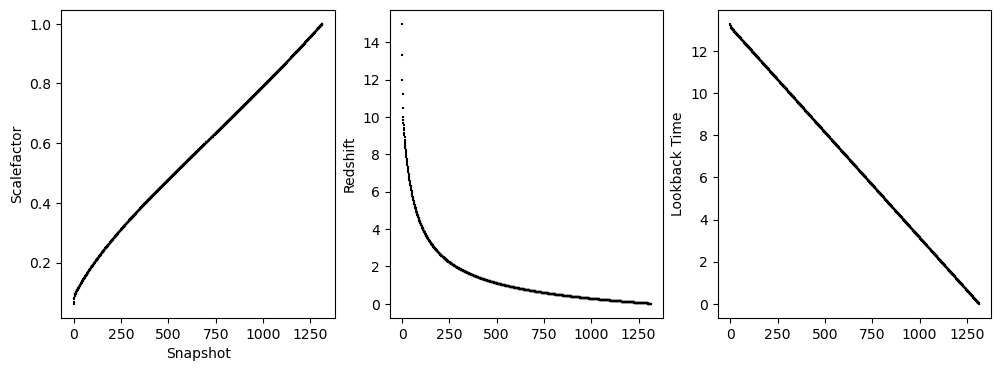

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(12,4))

snapnum, scf_list = rvs.get_scf_high_frequency(run)

axs[0].scatter(snapnum, scf_list, marker='+', color='k', s=1)

z_list = 1/scf_list - 1

axs[1].scatter(snapnum, z_list, marker='+', color='k', s=1)

header = rvs.read_header_high_frequency(run, nsnaps-1) ## read z=0 header for cosmology to get age

omega_m = header['Omega0']
hubble_param = header['HubbleParam']

age_list = scalefactor_to_age(scf_list, hubble_param*100, omega_m)

axs[2].scatter(snapnum, age_list, marker='+', color='k', s=1)

axs[0].set_xlabel('Snapshot')
axs[0].set_ylabel('Scalefactor')
axs[1].set_ylabel('Redshift')
axs[2].set_ylabel('Lookback Time')

plt.show()

## Loading in data from mini snaps

In [17]:
snap = nsnaps - 1

header = rvs.read_header_high_frequency(run, nsnaps-1)
print(header['Time'])
prt_cat = rvs.read_individual_high_frequency(run, snap)

0.9999999999999998


In [18]:
prt_cat.keys()

dict_keys(['PartType0/Coordinates', 'PartType0/ElectronAbundance', 'PartType0/InternalEnergy', 'PartType0/Masses', 'PartType0/ParticleIDs', 'PartType0/Potential', 'PartType0/Velocities', 'PartType1/Coordinates', 'PartType1/ParticleIDs', 'PartType1/Potential', 'PartType1/Velocities', 'PartType4/Coordinates', 'PartType4/Masses', 'PartType4/ParticleIDs', 'PartType4/Potential', 'PartType4/Velocities'])

For the RVS the particles associated with the target are drawn from a region of size

$$\operatorname{max}\left[ 100~{\rm ckpc\,h^{-1}}, 2R_{200,c} \right]$$

where $R_{200,c}$ is selected from final DMO zoom at $z=0$ (in ${\rm ckpc\,h^{-1}}$ units)

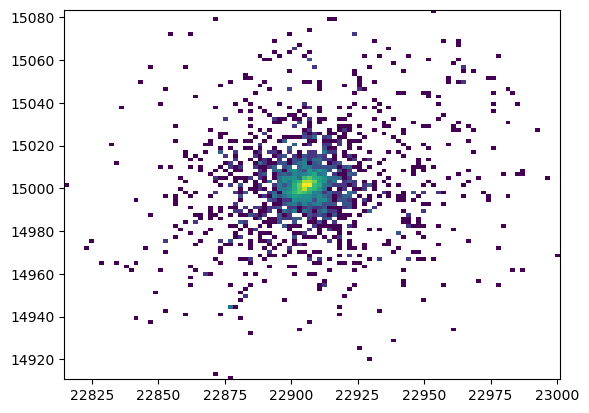

In [21]:
plt.hist2d( prt_cat['PartType1/Coordinates'][:,0], prt_cat['PartType1/Coordinates'][:,1], bins=100, norm='log' )

plt.show()